In [ ]:
CSV_PATH = "/mnt/ceph-hdd/cold/nim00020/hannibal_data/cancerscout_metadata/cancerscout_semantic_organized.csv"
import pandas as pd
df = pd.read_csv(CSV_PATH)
df.columns

Index(['patient ID', 'sex', 'age at diagnosis', 'lepidic', 'acinous',
       'papillary', 'micropapillary', 'solid', 'mucinous', 'G', 'pT',
       'pSize [cm]', 'pN', 'R', 'M ', 'side of metastasis', 'pUICC', 'TPS',
       'CPS', 'IC', 'TTF-1', 'Ki-67', 'OS-Status', 'OS-Time [months]',
       'subtype', 'subtype [%]', 'internal_split', 'train_eval_split',
       'inst_dataset', 'num_instances', 'tumor_cells', 'stromal_cells',
       'lymphocytes', 'others', 'neutrophils', 'epithelial_cells', 'filename'],
      dtype='object')

In [10]:
# df['train_eval_split'].unique()
df['internal_split'].unique()
df['num_instances']


0      8287.0
1     14604.0
2     10105.0
3     10812.0
4      9313.0
5     15296.0
6      9731.0
7      9670.0
8     13201.0
9      7023.0
10     2561.0
11     4639.0
12    14615.0
13    13259.0
14     8522.0
15     6943.0
16     6968.0
17     2108.0
18      706.0
19     1116.0
20     1026.0
21     2355.0
22     1731.0
23     1425.0
24      926.0
25     2343.0
26     3988.0
27     3972.0
Name: num_instances, dtype: float64

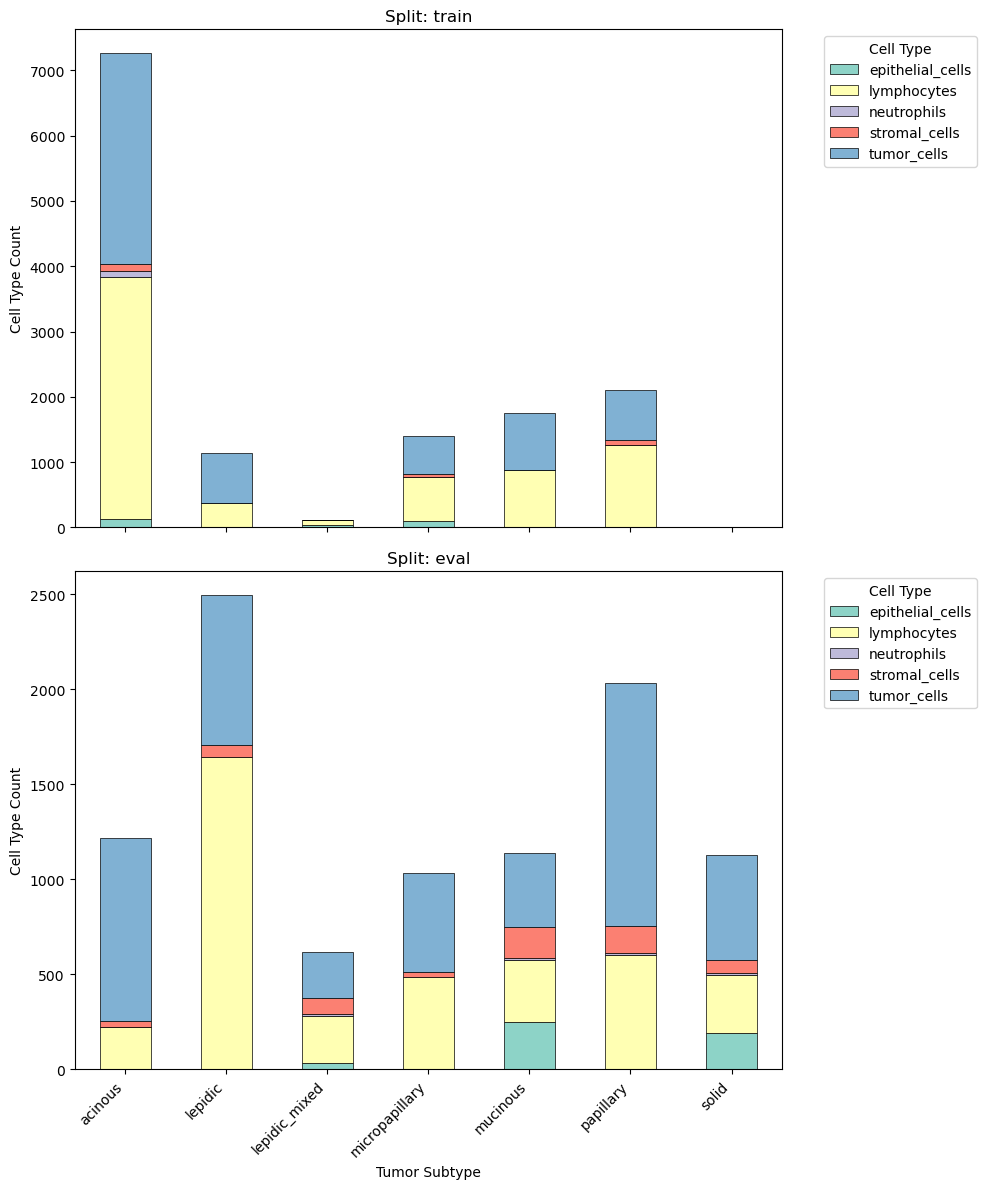

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrame (replace with your actual data)
# df = pd.read_csv('your_data.csv')

# Let's assume your columns are:
# - split: 'train', 'val', 'test'
# - tumor_subtype: e.g., 'Luminal', 'Basal', 'HER2'
# - cell type columns: 'CD8_T', 'Treg', 'Macrophage', 'B_cell', 'NK_cell'

# Step 1: Melt the DataFrame to long format for plotting
# Keep only cell type columns
cell_type_cols = ["epithelial_cells", "tumor_cells", "stromal_cells", "neutrophils", "lymphocytes"]

# Melt the data: each row becomes (split, tumor_subtype, cell_type, count)
df_melted = df.melt(
    id_vars=['train_eval_split', 'subtype'],
    value_vars=cell_type_cols,
    var_name='cell_type',
    value_name='count'
)

# Step 2: Group by split and tumor_subtype to get total counts per group
# We'll create a pivot table for plotting
pivot_df = df_melted.groupby(['train_eval_split', 'subtype', 'cell_type'])['count'].sum().unstack(level='cell_type').fillna(0)

# Step 3: Plot stacked bar plots for each split
splits = df['train_eval_split'].unique()

fig, axes = plt.subplots(nrows=len(splits), ncols=1, figsize=(10, 6 * len(splits)), sharex=True)

# Define colors for cell types
colors = plt.cm.Set3.colors  # or use a custom list: ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for idx, split in enumerate(splits):
    ax = axes[idx]
    data = pivot_df.loc[split]  # Get data for this split

    # Stack the bars
    data.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.5)

    ax.set_title(f'Split: {split}')
    ax.set_ylabel('Cell Type Count')
    ax.set_xlabel('Tumor Subtype')
    ax.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()




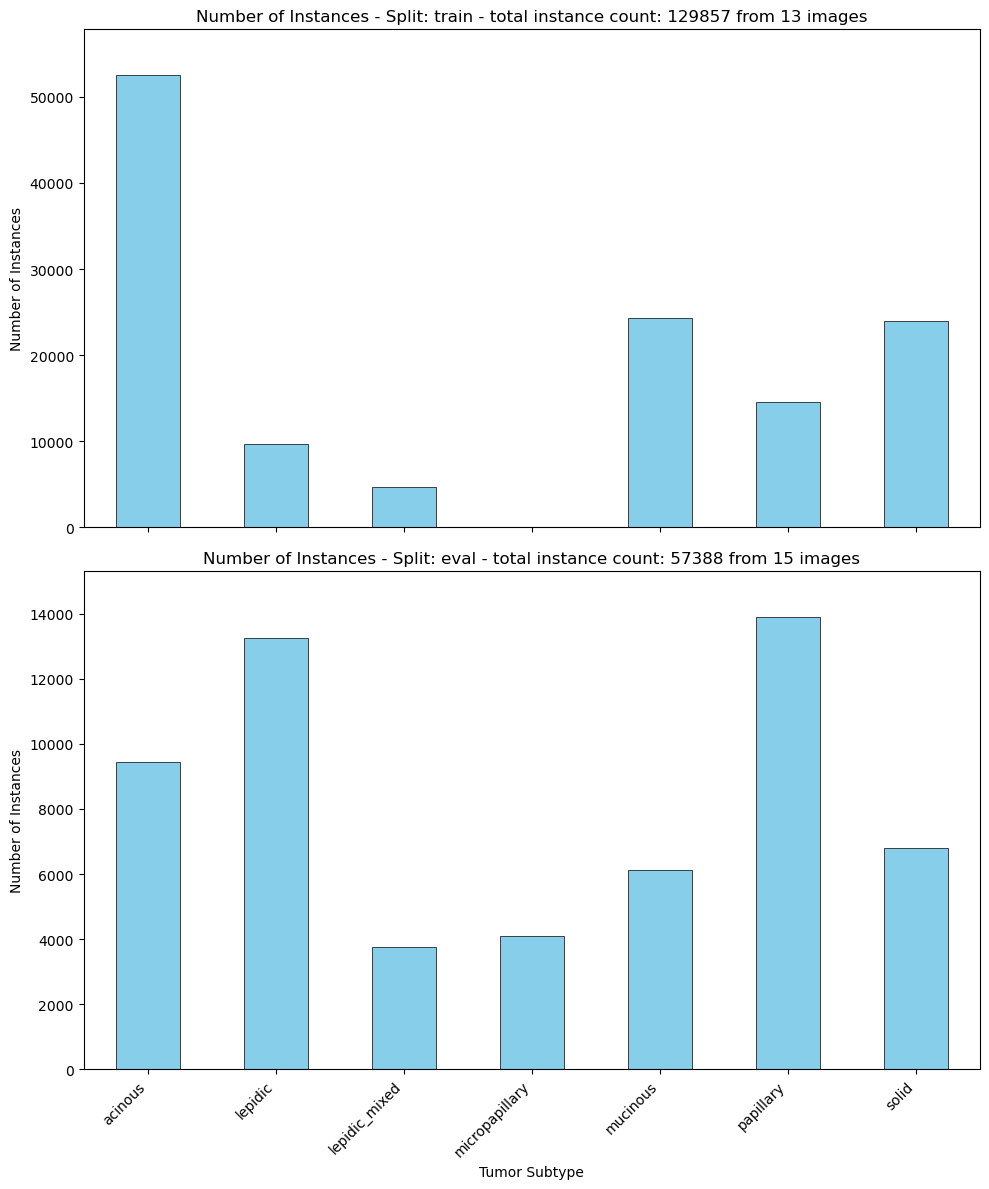

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame `df` has:
# - 'split' (e.g., 'train', 'eval')
# - 'tumor_subtype' (e.g., 'Luminal', 'Basal', 'HER2')
# - 'num_instances' (a scalar per row, e.g., number of samples per subtype in that split)

# Step 1: Group by split and tumor_subtype to get total num_instances per subtype per split
# (assuming each row is one sample or one subtype entry)
grouped_df = df.groupby(['train_eval_split', 'subtype'], as_index=False)['num_instances'].sum()

# Step 2: Pivot the data so that each split becomes a column
pivot_df = grouped_df.pivot(index='subtype', columns='train_eval_split', values='num_instances')

# Step 3: Plot bar plots — one per split
splits = df['train_eval_split'].unique()

fig, axes = plt.subplots(nrows=len(splits), ncols=1, figsize=(10, 6 * len(splits)), sharex=True)

for idx, split in enumerate(splits):
    ax = axes[idx]
    data = pivot_df[split]  # Get num_instances for this split

    # Create bar plot
    data.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black', linewidth=0.5)

    ax.set_title(f'Number of Instances - Split: {split} - total instance count: {int(pivot_df[split].sum())} from {len(df[(df["train_eval_split"] == split) & (df["num_instances"].notna())])} images')
    ax.set_ylabel('Number of Instances')
    ax.set_xlabel('Tumor Subtype')
    ax.set_ylim(0, data.max() * 1.1)  # Add some padding on top

    # Rotate x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [23]:
print(split)
len(df[(df["train_eval_split"] == split) & (df["num_instances"].notna())])


eval


15